In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from dynamax.hidden_markov_model import PoissonHMM
from scipy.optimize import minimize_scalar
import os
from tqdm import tqdm

%matplotlib widget

In [2]:

def calculate_cloned_transition_matrix(alpha, sequenceLength, nSequences, verbose=False, transition_epsilon=1e-8):

    # the total number of states is the number of sequences times the sequence length and we add one for the non-sequence state
    nStates = sequenceLength * nSequences + 1

    gamma = (1 - alpha) / (2 * sequenceLength * nSequences) # this is the probability of transitioning into or out of any of the sequence states
    beta = 1 - gamma # this is the probability of transitioning between states in the sequence
    if verbose:
        print(f"alpha: {alpha}, beta: {beta}, gamma: {gamma}")

    # initialize the transition matrix with zeros and then fill in the appropriate entries
    P = np.zeros((1 + 2 * sequenceLength * nSequences, 1 + 2 * sequenceLength * nSequences))
    P[0, 0] = alpha

    # define the transition probabilities into the sequences (can transition into any part of the sequence with equal probability)
    P[0, 1:] = gamma

    # define the transition probabilities out of the sequences (can transition out of any part of the sequence with equal probability)
    P[1:, 0] = gamma

    # define the transition probabilities through the sequences
    start = None
    for i in range(nSequences):
        start = 1 if start is None else end + 1
        end = start + 2 * sequenceLength - 1

        for idx, j in enumerate(range(start, end + 1)):

            # set the beta values for the forward sequence
            if idx < sequenceLength - 1:
                P[j, j + 1] = beta

            # set the beta values for the reverse sequence (these are the cloned states that have the same emission probabilities as the forward sequence states)
            elif idx > sequenceLength:
                P[j, j - 1] = beta
            else:
                P[j, 0] = 1

    # Tiny smoothing avoids exact zeros that can make EM objective report -inf via log(0).
    if transition_epsilon is not None and transition_epsilon > 0:
        P = P + transition_epsilon
        P = P / P.sum(axis=1, keepdims=True)

    return P


alpha: 0.1, beta: 0.9775, gamma: 0.0225


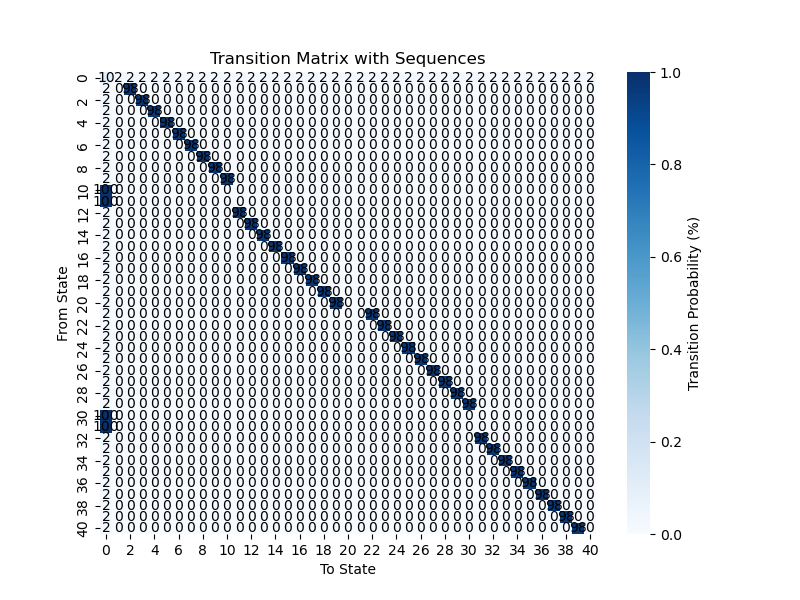

In [3]:

alpha = 0.1 # this is the probability of staying in the non sequence state. This is the only free parameter we have to set, the rest of the transition probabilities are determined by this and the sequence length and number of sequences
sequenceLength = 10 # number of latent states in each sequence
nSequences = 2 # total number of sequences

# Compute the transition matrix given the free paramerters
P = calculate_cloned_transition_matrix(alpha, sequenceLength, nSequences, verbose=True)
nStates = P.shape[0]

# plot the transition matrix
plt.figure(figsize=(8, 6))
sns.heatmap(P, cmap="Blues", cbar_kws={"label": "Transition Probability (%)"}, vmin=0, vmax=1)
# overlay the numbers for the transition probabilities
for i in range(nStates):
    for j in range(nStates):
        plt.text(j + 0.5, i + 0.5, f"{(P[i, j] * 100):.0f}", ha="center", va="center", color="black")
plt.title("Transition Matrix with Sequences")
plt.xlabel("To State")
plt.ylabel("From State")

plt.show()

In [4]:
# simulate data from this transition matrix
Nsteps = 20_000
states = np.zeros(Nsteps, dtype=int)
for t in range(1, Nsteps):
    states[t] = np.random.choice(nStates, p=P[states[t-1]])

(41, 100)
[(1, 11), (2, 12), (3, 13), (4, 14), (5, 15), (6, 16), (7, 17), (8, 18), (9, 19), (10, 20), (21, 31), (22, 32), (23, 33), (24, 34), (25, 35), (26, 36), (27, 37), (28, 38), (29, 39), (30, 40)]


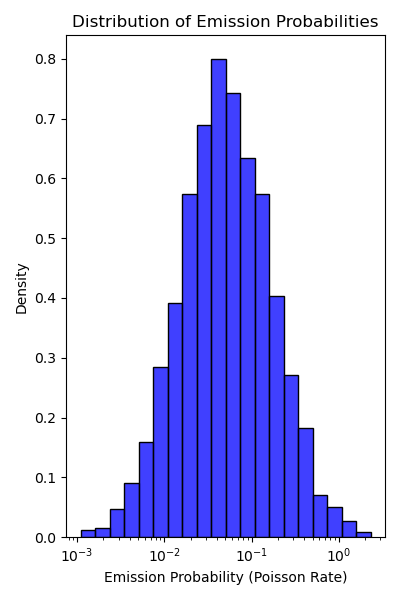

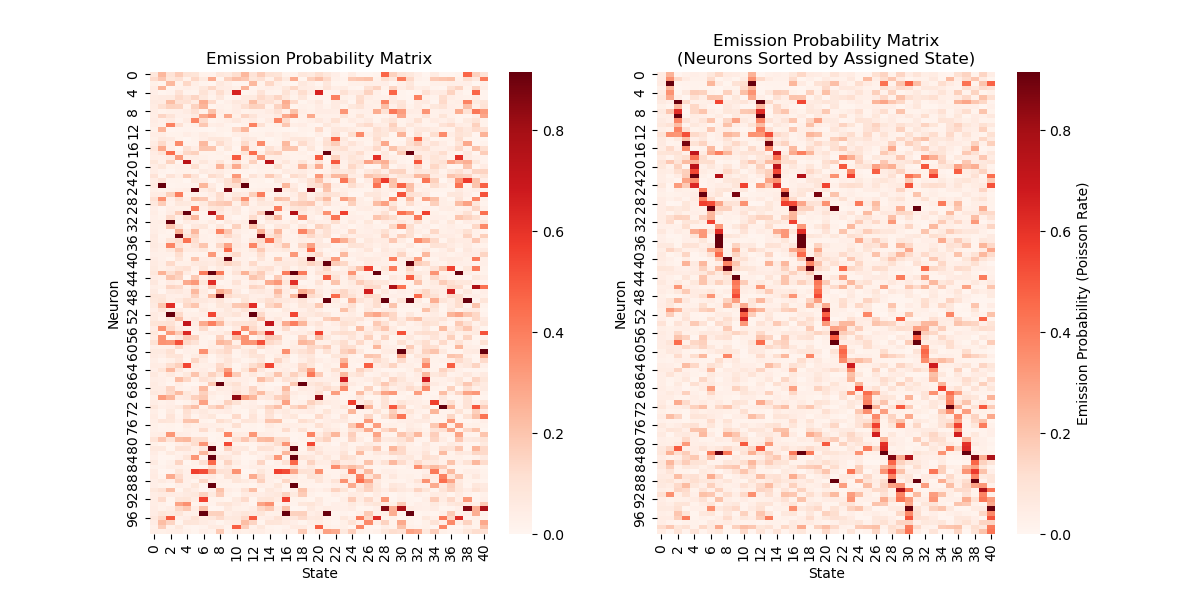

In [5]:
plot_len = 100

# randomly initialize the emission probabilities (poisson rates for each state and each neuron)
emission_dim = 100 # this corresponds to the number of neurons we are simulating

# draw the lambda parameters for the Poisson emissions from a lognormal distribution (this is a common choice for a prior on Poisson rates)
emission_prob = np.zeros((nStates, emission_dim))
print(emission_prob.shape)

nStates = P.shape[0]
pairs = []
for seq in range(nSequences):
    for step in range(sequenceLength):
        new_pair = (seq * 2 * sequenceLength + step + 1, seq * 2 * sequenceLength  + sequenceLength + step + 1)
        pairs.append(new_pair)
print(pairs)

for pair in pairs:
    # set the emission probabilities for the paired states to be the same (these are the cloned states that have the same emissions as the forward sequence states)
    emissions = np.random.lognormal(
        mean=-3,
        sigma=1.2,
        size=(emission_dim,)
    )
    emission_prob[pair[1], :], emission_prob[pair[0], :] = emissions, emissions

# set the emission prob in state zero to be the median across all the other states
emission_prob[0, :] = np.median(emission_prob[1:, :], axis=0)


# plot the distribution of emission probabilities for each state
plt.figure(figsize=(4, 6))
sns.histplot(emission_prob.flatten(), bins=20, stat='density', log_scale=(True, False), color="blue", edgecolor="black")
plt.title("Distribution of Emission Probabilities")
plt.xlabel("Emission Probability (Poisson Rate)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# simulate emissions from the HMM given the state sequence and the emission probabilities
emissions = np.zeros((Nsteps, emission_dim), dtype=int)
for t in range(Nsteps):
    emissions[t] = np.random.poisson(lam=emission_prob[states[t]])


# plot the emission prob matrix
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(emission_prob.T, cmap="Reds", ax=axs[0], vmin=0, vmax=np.percentile(emission_prob, 99))
axs[0].set_title("Emission Probability Matrix")
axs[0].set_xlabel("State")
axs[0].set_ylabel("Neuron")

# assign neurons to states (for each neuron, the state of maximal firing is the state that neuron is assigned to)
neuron_states = np.argmax(emission_prob, axis=0)

# sort the neurons by their assigned states and plot the emision prob matrix again
sorted_indices = np.argsort(neuron_states)
sns.heatmap(emission_prob[:, sorted_indices].T, cmap="Reds", ax=axs[1], cbar_kws={"label": "Emission Probability (Poisson Rate)"}, vmin=0, vmax=np.percentile(emission_prob, 99))
axs[1].set_title("Emission Probability Matrix\n(Neurons Sorted by Assigned State)")
axs[1].set_xlabel("State")
axs[1].set_ylabel("Neuron")
plt.show()



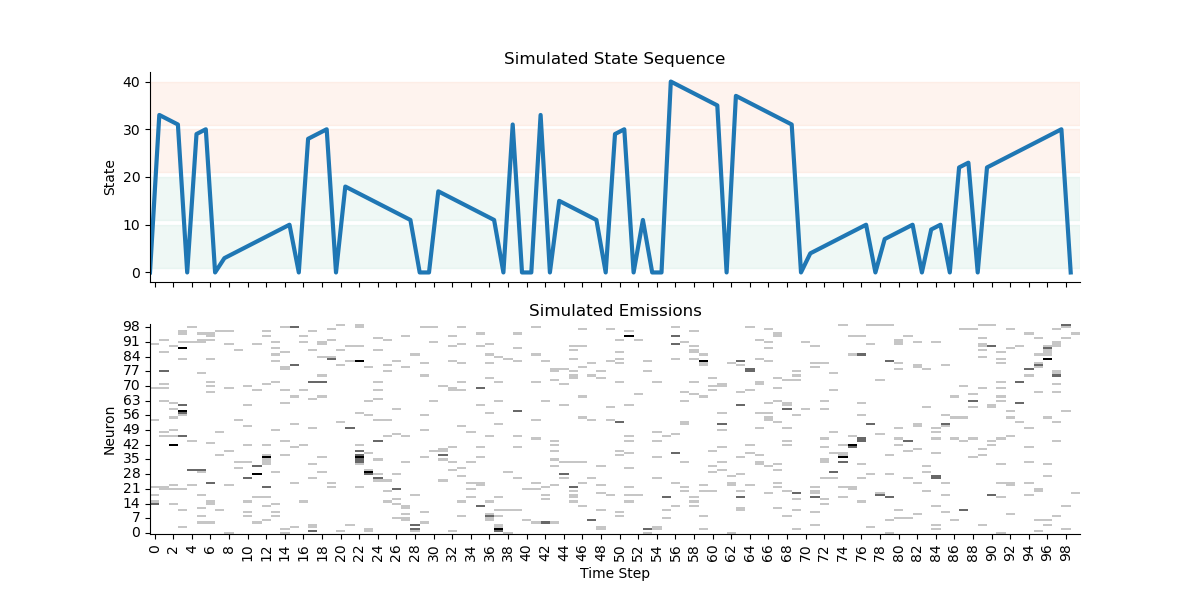

In [6]:
seq_colors = sns.color_palette("Set2", nSequences)


# sort the neurons by their assigned states and plot the emissions again
sorted_indices = np.argsort(neuron_states)
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sns.lineplot(x=np.arange(plot_len), y=states[:plot_len], ax=axs[0], linewidth=3)
axs[0].set_title("Simulated State Sequence")
axs[0].set_ylabel("State")
sns.heatmap(emissions[:plot_len, sorted_indices].T, cmap="Greys", ax=axs[1], vmax = 3)
# flip the y axis so that neuron 0 is at the bottom and neuron 19 is at the top
axs[1].invert_yaxis()
axs[1].set_title("Simulated Emissions")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Neuron")
# remove colorbar
axs[1].collections[0].colorbar.remove()

# shade the regions of the plot corresponding to the sequences
for i in range(nSequences):
    # forward states
    forward_start = 1 + i * 2 * sequenceLength
    forward_end = forward_start + sequenceLength

    # cloned reverse states
    reverse_start = forward_end
    reverse_end = reverse_start + sequenceLength

    axs[0].axhspan(forward_start, forward_end - 1, color = seq_colors[i], alpha=0.1)
    axs[0].axhspan(reverse_start, reverse_end - 1, color = seq_colors[i], alpha=0.1)

sns.despine()
plt.show()



In [ ]:
def make_folds(T, n_folds):
    indices = np.arange(T)
    return np.array_split(indices, n_folds)


def cv_objective(
    alpha,
    sequence_length,
    n_sequences,
    emissions,
    folds,
    num_iters=100,
    n_restarts=1,
    plot_dir=None
):

    fold_scores = []

    # Loop over the folds for cross-validation
    for fold_idx in range(len(folds)):

        # get the training and testing indices for this fold
        test_idx = folds[fold_idx]

        train_idx = np.setdiff1d(
            np.arange(len(emissions)),
            test_idx
        )

        # get the training and testing emissions for this fold
        train_emissions = emissions[train_idx]
        test_emissions = emissions[test_idx]

        # compute the transition matrix given the free parameters
        P = calculate_cloned_transition_matrix(
            alpha,
            sequence_length,
            n_sequences
        )

        nStates = P.shape[0]
        emission_dim = emissions.shape[1]

        best_ll = -np.inf

        # optional multiple EM restarts
        for seed in range(n_restarts):

            key = jr.PRNGKey(seed)

            hmm = PoissonHMM(
                nStates,
                emission_dim
            )

            # initialize emissions uniformly
            initial_rates = np.mean(
                train_emissions,
                axis=0,
                keepdims=True
            )

            initial_rates = np.repeat(
                initial_rates,
                nStates,
                axis=0
            )

            # add some noise to the initial rates to break symmetry
            initial_rates += 0.001 * np.random.normal(size=initial_rates.shape)

            # ensure all rates are positive
            initial_rates = np.clip(initial_rates, a_min=1e-3, a_max=None)

            # convert to jax arrays
            initial_rates = jnp.array(initial_rates)

            params, props = hmm.initialize(
                key,
                transition_matrix=P,
                emission_rates=initial_rates
            )

            # freeze transitions
            props.transitions.transition_matrix.trainable = False

            # EM fit
            params, lls = hmm.fit_em(
                params,
                props,
                train_emissions,
                num_iters=num_iters,
                verbose=False
            )

            if plot_dir is not None:
                plt.figure()
                plt.plot(np.asarray(lls))
                plt.title(f"EM Convergence for Fold {fold_idx + 1}")
                plt.xlabel("EM Iteration")
                plt.ylabel("Log-Likelihood")
                plt.tight_layout()
                plt.savefig(os.path.join(plot_dir, f"fold_{fold_idx + 1}_em_convergence.png"))
                plt.close()




            # evaluate held-out likelihood
            test_ll = hmm.marginal_log_prob(
                params,
                test_emissions
            )

            if test_ll > best_ll:
                best_ll = test_ll

        fold_scores.append(best_ll)

    # negative because minimize_scalar minimizes
    return -np.mean(fold_scores)





In [7]:
def enforce_cloned_emissions(rates, sequenceLength, nSequences):
    '''
    This function takes in a matrix of emission rates and averages the rates for the forward and reverse states in each sequence to enforce that the cloned states have the same emissions as the original states.
    This is used to enforce the constraint that the cloned states have the same emissions as the original states after fitting the model.
    '''

    tied_rates = rates.copy()

    for i in range(nSequences):

        forward_start = 1 + i * 2 * sequenceLength
        forward_end = forward_start + sequenceLength

        reverse_start = forward_end
        reverse_end = reverse_start + sequenceLength

        # average forward + reverse
        avg = (
            tied_rates[forward_start:forward_end]
            + tied_rates[reverse_start:reverse_end]
        ) / 2

        tied_rates[forward_start:forward_end] = avg
        tied_rates[reverse_start:reverse_end] = avg

    return tied_rates

In [ ]:
# fit the model with the correct hyperparameters
save_dir = r'C:\Users\srafi\OneDrive\NeuroStatsLab\sequence-detection-figures\vanilla-HMM-fit-to-cloned-100-emission-10sequenceLength-20_000samples-enforce-cloned-emissions-5-20-26'
use_cloned_emissions = True # whether to enforce that the cloned states have the same emissions

num_iters = 30
nStarts = 50

# compute the transition matrix given the free parameters
P = calculate_cloned_transition_matrix(
    alpha,
    sequenceLength,
    nSequences
)
best_ll = -np.inf
best_model = None
best_params = None
all_lls = []

# random P
P = None

for seed in range(nStarts):

    current_save_dir = os.path.join(save_dir, f"restart_{seed}")
    os.makedirs(current_save_dir, exist_ok=True)

    # set random seed for reproducibility
    np.random.seed(seed)

    # define the model
    hmm = PoissonHMM(
        nStates,
        emission_dim
    )

    #set the initial_emission_rates as the mean rate for each neuron across all time points
    initial_emission_rates = emissions.mean(axis=0)

    # convert to matrix with shape (nStates, emission_dim)
    initial_emission_rates = np.repeat(initial_emission_rates[None, :], nStates, axis=0)

    # add some noise to the initial rates to break symmetry
    initial_emission_rates += 1e-6 * np.random.normal(size=initial_emission_rates.shape)

    # make sure all rates are positive
    initial_emission_rates = np.clip(initial_emission_rates, a_min=1e-9, a_max=3)

    # initialize the model parameters
    params, props = hmm.initialize(
        jr.PRNGKey(seed),
        transition_matrix=P,
        emission_rates=initial_emission_rates
    )

    # freeze transitions
    #props.transitions.transition_matrix.trainable = False


    lls = []
    for itr in tqdm(range(num_iters)):


        params, marginal_ll = hmm.fit_em(
            params,
            props,
            emissions,
            num_iters=1,
            verbose=False
        )

        lls.append(marginal_ll)

        # get current rates
        rates = np.array(params.emissions.rates)

        # enforce that the cloned states have the same emissions as the original states after each EM iteration
        if use_cloned_emissions:
            tied_rates = enforce_cloned_emissions(
                rates,
                sequenceLength,
                nSequences
            )
        else:
            tied_rates = rates


        # replace emissions.rates immutably
        params = params._replace(
            emissions=params.emissions._replace(
                rates=jnp.array(tied_rates)
            )
        )

    # plot the EM convergence
    plt.figure()
    plt.plot(np.asarray(lls))
    plt.title(f"EM Convergence for Restart {seed + 1}")
    plt.xlabel("EM Iteration")
    plt.ylabel("Log-Likelihood")
    plt.tight_layout()
    plt.savefig(os.path.join(current_save_dir, f"em_convergence.png"))
    plt.close()

    # plot the transition matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(np.array(params.transitions.transition_matrix), cmap="Blues", cbar_kws={"label": "Transition Probability (%)"}, vmin=0, vmax=1)
    # overlay the numbers for the transition probabilities
    for i in range(nStates):
        for j in range(nStates):
            plt.text(j + 0.5, i + 0.5, f"{(params.transitions.transition_matrix[i, j] * 100):.0f}", ha="center", va="center", color="black")
    plt.title("Learned Transition Matrix")
    plt.xlabel("To State")
    plt.ylabel("From State")
    plt.tight_layout()
    plt.savefig(os.path.join(current_save_dir, f"learned_transition_matrix.png"))
    plt.close()

    all_lls.append(lls[-1])
    if lls[-1] > best_ll:
        best_ll = lls[-1]
        best_model = hmm
        best_params = params




 13%|█▎        | 4/30 [00:12<01:18,  3.01s/it]

In [ ]:
# plot the distribution of log-likelihoods across random restarts
plt.figure(figsize=(6, 4))
sns.histplot(np.array(all_lls), stat='count')
plt.title("Log-Likelihoods Across 50 Random Restarts")
plt.xlabel("Log-Likelihood")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
hmm = best_model
params = best_params

# get the inferred state sequence
post = hmm.smoother(params, emissions)
inferred_states = np.argmax(post.smoothed_probs, axis=1)

In [ ]:
from scipy.optimize import linear_sum_assignment

def poisson_distance(true_rates, learned_rates, eps=1e-5):
    distance_matrix = np.zeros((true_rates.shape[0], learned_rates.shape[0]))
    for i in range(true_rates.shape[0]):
        for j in range(learned_rates.shape[0]):
            # compute the poisson distance between the true and learned rates for this state pair
            distance_matrix[i, j] = ((np.log(true_rates[i] + eps) - np.log(learned_rates[j] + eps))**2).mean()
    return distance_matrix

# get the learned emission probabilities from the best model
learned_emission_prob = np.array(params.emissions.rates)

true_rates = emission_prob
learned_rates = np.array(learned_emission_prob)

# distance matrix
distance_matrix = poisson_distance(
    true_rates,
    learned_rates
)



# Hungarian assignment minimizes total distance
row_ind, col_ind = linear_sum_assignment(distance_matrix)

matching_distances = distance_matrix[row_ind, col_ind]

print("Mean matched distance:", matching_distances.mean())

# plot the original and matched correlation matrices
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
sns.heatmap(distance_matrix, cmap="pink", cbar_kws={"label": "Distance"},  ax=axs[0,0])
axs[0,0].set_title("Distance Matrix Before Assignment")
sns.heatmap(distance_matrix[row_ind][:, col_ind], cmap="pink", cbar_kws={"label": "Distance"}, ax=axs[1,0])
axs[1,0].set_title("Distance Matrix After Optimal Assignment\nMean matched distance = {:.2f}".format(matching_distances.mean()))
axs[0,0].set_xlabel("")
axs[0,0].set_ylabel("True State")
axs[1,0].set_xlabel("Learned State")
axs[1,0].set_ylabel("True State")
#colorbar label
axs[0,0].collections[0].colorbar.set_label("")
axs[1,0].collections[0].colorbar.set_label("")
# plot the unity line
axs[0,1].plot([0, np.max(true_rates)], [0, np.max(learned_rates)], 'k--', alpha=0.5)
sns.scatterplot(x=true_rates[row_ind, :].flatten(), y=learned_rates[col_ind, :].flatten(), ax=axs[0,1], alpha=0.5)

axs[0,1].set_title("Scatter Plot of True vs Learned Rates")
axs[0,1].set_xlabel("True Rates")
axs[0,1].set_ylabel("Learned Rates")
# plot the sorted transition matrix
sns.heatmap(np.array(params.transitions.transition_matrix)[col_ind][:, col_ind], cmap="Blues", cbar_kws={"label": "Transition Probability (%)"}, vmin=0, vmax=1, ax=axs[1,1])
# overlay the numbers for the transition probabilities
for i in range(nStates):
    for j in range(nStates):
        axs[1,1].text(j + 0.5, i + 0.5, f"{(params.transitions.transition_matrix[col_ind][:, col_ind][i, j] * 100):.0f}", ha="center", va="center", color="black")
axs[1,1].set_title("Learned Transition Matrix\n(States sorted by minimum distance)")
axs[1,1].set_xlabel("To State")
axs[1,1].set_ylabel("From State")
# remove colorbar
axs[1,1].collections[0].colorbar.remove()
plt.tight_layout()
plt.show()



In [ ]:
# sort the inferred states according to the optimal assignment
mapping = dict(zip(col_ind, row_ind))

inferred_states_sorted = np.array([
    mapping[s] for s in np.array(inferred_states)
])

# plot the latent trajectory and the correspodning emissions for the best model sorted by the optimal assignment
sorted_indices = col_ind

# sort the neurons based on their assigned states and plot the emissions again
learned_emission_prob_sorted = learned_emission_prob[sorted_indices]
neuron_sorted_indices = np.argsort(np.argmax(learned_emission_prob_sorted, axis=0))


fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# plot the true state sequence and the inferred state sequence on top of each other
sns.lineplot(x=np.arange(plot_len), y=states[:plot_len], ax=axs[0], linewidth=3, label="True State")
sns.lineplot(x=np.arange(plot_len), y=inferred_states_sorted[:plot_len], ax=axs[0], linewidth=2, alpha=0.7, label="Inferred State")
axs[0].set_title("Simulated State Sequence")
axs[0].set_ylabel("State")
axs[0].legend()

# plot the emissions sorted by the optimal assignment
sns.heatmap(emissions[:plot_len, neuron_sorted_indices].T, cmap="Greys", ax=axs[1], vmax = 3)
axs[1].invert_yaxis()
axs[1].set_title("Simulated Emissions")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Neuron\n(sorted by learned state)")
# remove colorbar
axs[1].collections[0].colorbar.remove()
# shade the regions of the plot corresponding to the sequences
for i in range(nSequences):
    # forward states
    forward_start = 1 + i * 2 * sequenceLength
    forward_end = forward_start + sequenceLength

    # cloned reverse states
    reverse_start = forward_end
    reverse_end = reverse_start + sequenceLength

    axs[0].axhspan(forward_start, forward_end - 1, color = seq_colors[i], alpha=0.1)
    axs[0].axhspan(reverse_start, reverse_end - 1, color = seq_colors[i], alpha=0.1)
sns.despine()
plt.show()


In [ ]:

plot_dir = r"C:\Users\srafi\OneDrive\NeuroStatsLab\sequence-detection-figures\cloned-model-fits-5-15-26"

candidate_lengths = [10]
candidate_sequences = [2]
candidate_alphas = [0.1, 0.3, 0.5, 0.7]

folds = make_folds(
    T=len(emissions),
    n_folds=5
)

best_score = np.inf
best_model = None

all_scores = np.zeros((len(candidate_lengths), len(candidate_sequences), len(candidate_alphas)))

# Loop over the candidate sequence numbers and lengths for a grid search
for i, L in enumerate(candidate_lengths):
    for j, S in enumerate(candidate_sequences):
        for k, A in enumerate(candidate_alphas):

            current_plot_dir = os.path.join(plot_dir, f"L{L}_S{S}_A{A:.2f}")
            os.makedirs(current_plot_dir, exist_ok=True)


            print(f"Testing L={L}, S={S}, alpha={A}")

            score = cv_objective(
                A,
                L,
                S,
                emissions,
                folds,
                num_iters=20,
                n_restarts=1,
                plot_dir=current_plot_dir
            )

            print(f"Score: {score:.2f}\n")


            all_scores[i, j, k] = score

            if score < best_score:

                best_score = score

                best_model = {
                    "sequence_length": L,
                    "n_sequences": S,
                    "alpha": A,
                    "score": score
                }

print("\nBest model:")
print(best_model)

In [ ]:
# plot the scores as a function of alpha for each sequence length and number of sequences
plt.figure()
plt.plot(candidate_alphas, all_scores[0, 0, :])
plt.title("CV Score as a Function of Alpha")
plt.xlabel("Alpha")
plt.ylabel("CV Score (Negative Log-Likelihood)")
plt.show()
